# Implementing scramble control

The threshold for gene-gene correlations and directional correlations must be based on the scramble based control. Additionally, some bootstrapping might be useful to reduce the fluctuations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, rankdata
from tqdm.auto import tqdm

## Helper functions

In [2]:
def read_input_matrix(path_to_matrix: str) -> (int, np.ndarray):
    """
    Reads an input matrix from a specified file path and returns its dimensions and content.

    Args:
        path_to_matrix (str): The file path to the matrix file. The file should contain
                              a comma-separated matrix of integers.

    Returns:
        tuple: A tuple containing:
            - int: The number of rows in the matrix.
            - np.ndarray: The matrix as a NumPy array. If the matrix is a single value,
                          it is reshaped into a 1x1 array.

    Raises:
        ValueError: If the file cannot be loaded.
    """
    try:
        matrix = np.loadtxt(path_to_matrix, dtype=int, delimiter=',')
        if matrix.ndim == 0:
            matrix = matrix.reshape((1,1))
        return matrix.shape[0], matrix
    except Exception as e:
        raise ValueError(f"Error loading matrix from {path_to_matrix}: {e}")

def get_param_data(param_df, param_index):
    """
    Extracts parameters used in a simulation and flattens them with labeled keys.

    Args:
        param_df (pd.DataFrame): Parameter sheet with gene and interaction parameters.
        param_index (str): String like '12_13' denoting which rows were used.

    Returns:
        dict: Flat dictionary with keys like 'gene_1_p_on', 'gene_2_p_off', etc.,
              and interaction terms left as-is.
    """
    gene_terms = ["k_on", "k_off", "mrna_half_life", "protein_half_life", 
                  "k_prod_protein", "k_prod_mRNA"]
    extra_terms = ["pair_id", "gene_id"]

    rows = [int(i) for i in param_index.split("_")]
    selected_rows = param_df.iloc[rows]

    param_dict = {}

    # Gene-specific parameters
    for i, row in selected_rows.iterrows():
        gene_id = int(i + 1)
        for term in gene_terms:
            key = f"{term}_gene_{gene_id}"
            param_dict[key] = row[term]
        #add degradation terms from half_life
        mRNA_deg_key = f"k_deg_mRNA_gene_{gene_id}"
        mRNA_half_life_key = f"mrna_half_life_gene_{gene_id}"
        param_dict[mRNA_deg_key] = np.log(2)/param_dict[mRNA_half_life_key]
        protein_deg_key = f"k_deg_protein_gene_{gene_id}"
        protein_half_life_key = f"protein_half_life_gene_{gene_id}"
        param_dict[protein_deg_key] = np.log(2)/param_dict[protein_half_life_key]
    # Interaction parameters (take from first row)
    interaction_cols = [
        col for col in param_df.columns 
        if col not in gene_terms + extra_terms
    ]
    interaction_values = param_df.loc[rows[0], interaction_cols]
    for col in interaction_cols:
        param_dict[col] = interaction_values[col]

    return param_dict

In [3]:
def calculate_pairwise_gene_gene_correlation_matrix(simulation_at_t1, gene_list):
    correlations = {}
    for gene_1 in gene_list:
        for gene_2 in gene_list:
            gene_gene_corr = spearmanr(simulation_at_t1[f"{gene_1}_mRNA"], simulation_at_t1[f"{gene_2}_mRNA"]).correlation
            correlations[f"{gene_1}-{gene_2}"] = gene_gene_corr
    correlation_matrix = dict_to_matrix(correlations, gene_list)
    return correlation_matrix

def dict_to_matrix(correlation_dict, gene_list):
    
    matrix = pd.DataFrame(index=gene_list, columns=gene_list, dtype=float)
    for key, value in correlation_dict.items():
        g1, g2 = key.split("-")
        matrix.loc[g1, g2] = value
    return matrix

In [4]:
def calculate_twin_random_pair_correlations(simulation_two_time, simulation_single_time, gene_list):
    """
    Computes twin and random pairwise correlation matrices at a given time point.

    Parameters
    ----------
    simulation_single_time : pd.DataFrame
        Subset of simulation data at a single time point. Must contain:
        - 'replicate' column (1 for twin A, 2 for twin B)
        - 'clone_id'
        - '{gene}_mRNA' for each gene in gene_list

    gene_list : list of str
        List of gene names (without "_mRNA" suffix) to analyze.

    Returns
    -------
    twin_correlation_matrix : pd.DataFrame
        Matrix of gene-gene Spearman correlations computed between true twin pairs.

    random_correlation_matrix : pd.DataFrame
        Matrix of gene-gene Spearman correlations between randomly paired clones.
    """
    # Separate replicate 1 and replicate 2
    rep_0 = simulation_single_time[simulation_single_time['replicate'] == 1].reset_index(drop=True)
    rep_1 = simulation_single_time[simulation_single_time['replicate'] == 2].reset_index(drop=True)
    # Calculate correlations using matched twin pairs
    twin_correlation_dict = calculate_pair_correlation(rep_0, rep_1, gene_list, type_comparison="twin")
    twin_correlation_matrix = dict_to_matrix(twin_correlation_dict, gene_list)
    # Calculate correlations using randomly shuffled pairs
    
    random_rep_0 = simulation_two_time[simulation_two_time['replicate'] == 1]
    random_rep_1 = simulation_two_time[simulation_two_time['replicate'] == 2]
    random_rep_1_shuffled = random_rep_1.sample(frac=1, random_state=10100).reset_index(drop=True)
    random_correlation_dict = calculate_pair_correlation(random_rep_0, random_rep_1_shuffled, gene_list, type_comparison="random")
    random_correlation_matrix = dict_to_matrix(random_correlation_dict, gene_list)
    return twin_correlation_matrix, random_correlation_matrix

In [5]:
def calculate_pair_correlation(rep_0, rep_1, gene_list, type_comparison="twin"):
    """
    Computes gene-wise pairwise Spearman correlations between delta values across two replicates.

    Parameters
    ----------
    rep_0 : pd.DataFrame
        DataFrame for replicate 1, must include 'clone_id' and '{gene}_mRNA' columns.

    rep_1 : pd.DataFrame
        DataFrame for replicate 2, same structure as rep_0.

    gene_list : list of str
        List of gene names (without "_mRNA" suffix) to analyze.

    type_comparison : str, optional
        Type of comparison:
        - "twin": requires exact matching of `clone_id` between replicates.
        - "random": does not require matching clone_ids.

    Returns
    -------
    correlations : dict
        Dictionary of Spearman correlation values keyed as "gene1-gene2".
        Each value corresponds to correlation of Δgene1 vs Δgene2.
    """
    rep_0 = rep_0.reset_index(drop=True)
    rep_1 = rep_1.reset_index(drop=True)
    if type_comparison == "twin":
        rep_0 = rep_0.sort_values("clone_id").reset_index(drop=True)
        rep_1 = rep_1.sort_values("clone_id").reset_index(drop=True)
        if not rep_0["clone_id"].equals(rep_1["clone_id"]):
            raise ValueError("After sorting, clone_ids in rep_0 and rep_1 do not match.")

    correlations = {}
    for gene_1 in gene_list:
        for gene_2 in gene_list:
            delta_1 = rep_0[f"{gene_1}_mRNA"] - rep_1[f"{gene_1}_mRNA"]
            delta_2 = rep_0[f"{gene_2}_mRNA"] - rep_1[f"{gene_2}_mRNA"]
            corr = spearmanr(delta_1, delta_2).correlation
            correlations[f"{gene_1}-{gene_2}"] = corr
    return correlations

## Scramble baseline functions

In [6]:
def get_scrambled_correlations(df, gene_i, gene_j, n=10_000, p_val=0.01, method="spearman", seed=None):
    """
    Returns (null_corrs, abs_threshold) for the unordered pair {gene_i, gene_j}.
    abs_threshold is the (1 - p_val) quantile of |null_corrs| (two-sided).
    """
    # Data prep
    x = df[f"{gene_i}_mRNA"].to_numpy()
    y = df[f"{gene_j}_mRNA"].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    
    # Choose correlation function
    if method == "spearman":
        corr_func = lambda a, b: spearmanr(a, b)[0]  # returns (correlation, p-value)
    elif method == "pearson":
        corr_func = lambda a, b: pearsonr(a, b)[0]
    else:
        raise ValueError("method must be 'spearman' or 'pearson'")

    rng = np.random.default_rng(seed)
    n_obs = x.size
    null_corrs = np.empty(n, dtype=float)
    
    for k in range(n):
        perm = rng.permutation(n_obs)
        null_corrs[k] = corr_func(x, y[perm])

    # threshold
    thr = np.quantile(np.abs(null_corrs), 1.0 - p_val)
    return null_corrs, thr


def check_gene_gene_correlation_threshold(all_t1_t2_measurements,
                                          pairwise_gene_gene_correlation_matrix, 
                                          gene_list, 
                                          threshold=0.04,
                                          use_scramble = True,
                                          p_val_threshold = 0.01,
                                          verbose=False):
    """
    Splits gene-gene pairs based on absolute correlation threshold.

    Parameters
    ----------
    all_t1_t2_measurements : pd.DataFrame
        The cell-gene dataframe containing sample information.
    pairwise_gene_gene_correlation_matrix : pd.DataFrame
        A square matrix of gene-gene correlations (gene × gene).
    gene_list : list of str
        List of gene names, must match the matrix row/column order.
    threshold : float, optional
        Correlation magnitude threshold to separate regulated vs unregulated.
    use_scramble : bool, optional
        If True, uses scrambled correlations for comparison.
    p_val_threshold : float, optional
        P-value threshold for significance testing.
    verbose : bool, optional
        If True, plots the null distribution and threshold for each gene pair.
    
    Returns
    -------
    no_regulation : list of tuple
        Gene pairs (i, j) where abs(correlation) ≤ threshold.

    potential_regulation : list of tuple
        Gene pairs (i, j) where abs(correlation) > threshold.
    
    Note:
    1. If both use_scrambled is True and threshold is provided, a new threshold is calculated 
       based on the scrambled distribution and p_val_threshold.
    """
    no_regulation = []
    potential_regulation = []
    for i in range(len(gene_list)):
        for j in range(len(gene_list)):
            if i >= j:
                continue  # Skip diagonal
            corr_val = pairwise_gene_gene_correlation_matrix.values[i, j]
            pair = (gene_list[i], gene_list[j])
            rev_pair = (gene_list[j], gene_list[i])
            if use_scramble:
                null_dist, threshold = get_scrambled_correlations(all_t1_t2_measurements, gene_list[i], gene_list[j], n=10_000, p_val=p_val_threshold)
                p_value = np.mean(np.abs(null_dist) >= np.abs(corr_val))
                if verbose:
                    plt.figure(figsize=(6, 4))
                    plt.hist(null_dist, bins=50, color="skyblue", alpha=0.7, edgecolor="k")
                    plt.axvline(threshold, color="red", linestyle="--", label=f"+thr={threshold:.2e}")
                    plt.axvline(-threshold, color="red", linestyle="--", label=f"-thr={threshold:.2e}")
                    plt.axvline(corr_val, color="black", linestyle="-", label=f"actual={corr_val:.2e}")
                    plt.title(f"Scrambled correlations: {gene_list[i]} vs {gene_list[j]}, p-val = {p_value:.2e}")
                    plt.xlabel("Correlation")
                    plt.ylabel("Count")
                    plt.legend()
                    plt.tight_layout()
                    plt.show()
            if abs(corr_val) > threshold:
                    potential_regulation.append(pair)
                    potential_regulation.append(rev_pair)
            else:
                no_regulation.append(pair)
                no_regulation.append(rev_pair)
    return no_regulation, potential_regulation

## Random vs twin correlation

In [7]:
def generate_10k_random_shuffles_optimized(simulation_data, gene_list, n_shuffles=10000, random_state=42, scramble=False):
    """
    Generate exactly 10k different random shuffles with maximum vectorization.
    If scramble=True: shuffle within each replicate (destroys gene-gene relationships)
    If scramble=False: shuffle between replicates (preserves gene-gene relationships)
    """
    np.random.seed(random_state)
    
    rep_0 = simulation_data[simulation_data['replicate'] == 1].reset_index(drop=True)
    rep_1 = simulation_data[simulation_data['replicate'] == 2].reset_index(drop=True)
    gene_cols = [f"{gene}_mRNA" for gene in gene_list]
    min_cells = min(len(rep_0), len(rep_1))
    expr_0 = rep_0[gene_cols].iloc[:min_cells].values
    expr_1 = rep_1[gene_cols].iloc[:min_cells].values

    n_cells, n_genes = expr_0.shape
    
    if scramble:
        # NEW: Shuffle within each replicate independently for each gene
        # This destroys all gene-gene relationships within each replicate
        all_shuffle_indices_0 = np.array([[np.random.permutation(n_cells) for _ in range(n_genes)] for _ in range(n_shuffles)])
        all_shuffle_indices_1 = np.array([[np.random.permutation(n_cells) for _ in range(n_genes)] for _ in range(n_shuffles)])
    else:
        # ORIGINAL: Shuffle entire replicate (preserves gene-gene relationships)
        all_shuffle_indices = np.array([np.random.permutation(n_cells) for _ in range(n_shuffles)])
    
    # Vectorized processing in batches to manage memory
    batch_size = 100  # Process 100 shuffles at a time
    all_correlations = []
    
    for batch_start in tqdm(range(0, n_shuffles, batch_size)):
        batch_end = min(batch_start + batch_size, n_shuffles)
        
        batch_correlations = []
        
        for i in range(batch_start, batch_end):
            if scramble:
                # Shuffle each gene independently within each replicate
                expr_0_shuffled = np.column_stack([expr_0[all_shuffle_indices_0[i, j], j] for j in range(n_genes)])
                expr_1_shuffled = np.column_stack([expr_1[all_shuffle_indices_1[i, j], j] for j in range(n_genes)])
            else:
                # Original approach: shuffle entire replicate
                shuffle_idx = all_shuffle_indices[i]
                expr_0_shuffled = expr_0  # Keep rep_0 unchanged
                expr_1_shuffled = expr_1[shuffle_idx]
            
            deltas = expr_0_shuffled - expr_1_shuffled
            
            # Vectorized correlation matrix
            ranked_deltas = np.apply_along_axis(rankdata, 0, deltas)
            corr_matrix = np.corrcoef(ranked_deltas.T)
            
            # Store only upper triangle to save memory
            triu_indices = np.triu_indices(n_genes, k=1)
            batch_correlations.append(corr_matrix[triu_indices])
        
        all_correlations.extend(batch_correlations)
    
    # Convert to numpy array for efficient statistics
    all_correlations = np.array(all_correlations)  # Shape: (10000, n_gene_pairs)
    
    # Calculate comprehensive statistics
    random_stats = {
        'all_values': all_correlations.flatten(),
        'mean_per_pair': np.mean(all_correlations, axis=0),
        'std_per_pair': np.std(all_correlations, axis=0),
        'percentile_95': np.percentile(np.abs(all_correlations.flatten()), 95),
        'percentile_100': np.percentile(np.abs(all_correlations.flatten()), 100),
        'global_mean': np.mean(all_correlations),
        'global_std': np.std(all_correlations),
        'scramble_type': 'within_replicate' if scramble else 'between_replicate'
    }
    
    return random_stats

def differentiate_single_state_reg_and_multiple_states(potential_regulation, twin_correlation_matrix, random_correlation_matrix, gene_list, threshold_ratio=25):
    """
    Separates potential regulatory gene pairs into multiple-state vs single-state regulation.

    Parameters
    ----------
    potential_regulation : list of tuple
        List of gene pairs (gene_i, gene_j) with potential regulation.
    twin_correlation_matrix : pd.DataFrame
        Twin pair correlation matrix at time t2.
    random_correlation_matrix : pd.DataFrame
        Random pair correlation matrix at time t2.
    gene_list : list of str
        List of gene names (e.g., 'gene_1') in correct matrix order.
    threshold_ratio : float, optional
        Threshold for abs(random / twin) above which a pair is considered multi-state.
    Returns
    -------
    multiple_states_gene_pairs : list of tuple
        Gene pairs with abs(random / twin) >= threshold_ratio.

    single_state_regulation : list of tuple
        Gene pairs with abs(random / twin) < threshold_ratio.
    """
    multiple_states_gene_pairs = []
    single_state_regulation = []

    for gene_i, gene_j in potential_regulation:
        try:
            t_corr = twin_correlation_matrix.loc[gene_i, gene_j]
            r_corr = random_correlation_matrix.loc[gene_i, gene_j]

            if abs(r_corr / t_corr) >= threshold_ratio:
                multiple_states_gene_pairs.append((gene_i, gene_j))
            else:
                single_state_regulation.append((gene_i, gene_j))
        except ZeroDivisionError:
            # Handle case where twin correlation is 0
            raise ValueError(f"Division by zero for {gene_i} and {gene_j}")
        except KeyError:
            raise ValueError(f"Missing gene pair ({gene_i}, {gene_j}) in correlation matrices.")

    return multiple_states_gene_pairs, single_state_regulation

In [8]:
def calculate_single_pair_fast(rep_0, rep_1, gene_1, gene_2, 
                             type_comparison="twin", 
                             n_scrambles=1000):
    """
    Ultra-fast version for scrambled correlations of a single gene pair.
    Returns only the scrambled correlation distribution.
    """
    # Preprocessing
    rep_0 = rep_0.reset_index(drop=True)
    rep_1 = rep_1.reset_index(drop=True)
    
    if type_comparison == "twin":
        rep_0 = rep_0.sort_values("clone_id").reset_index(drop=True)
        rep_1 = rep_1.sort_values("clone_id").reset_index(drop=True)
        if not rep_0["clone_id"].equals(rep_1["clone_id"]):
            raise ValueError("After sorting, clone_ids in rep_0 and rep_1 do not match.")

    # Calculate deltas once
    delta_1 = rep_0[f"{gene_1}_mRNA"].values - rep_1[f"{gene_1}_mRNA"].values
    delta_2 = rep_0[f"{gene_2}_mRNA"].values - rep_1[f"{gene_2}_mRNA"].values
    
    n_samples = len(delta_1)
    scrambled_corrs = np.zeros(n_scrambles)
    
    # Vectorized scrambling
    np.random.seed(42)
    for i in tqdm(range(n_scrambles)):
        # Scramble only delta_1 to break the pairing
        indices = np.random.permutation(n_samples)
        scrambled_corrs[i] = spearmanr(delta_1[indices], delta_2).correlation
    return scrambled_corrs

def calculate_twin_pair_correlations(simulation_single_time, gene_list, gene_1, gene_2):
    """
    Computes twin pairwise correlations with bootstrap sampling for a specific gene pair.

    Parameters
    ----------
    simulation_single_time : pd.DataFrame
        Subset of simulation data at a single time point. Must contain:
        - 'replicate' column (1 for twin A, 2 for twin B)
        - 'clone_id'
        - '{gene}_mRNA' for each gene in gene_list

    gene_list : list of str
        List of gene names (without "_mRNA" suffix) to analyze.
        
    gene_1 : str
        First gene name for the correlation pair.
        
    gene_2 : str
        Second gene name for the correlation pair.

    Returns
    -------
    twin_correlations : list of float
        List of correlation values between gene_1 and gene_2 from bootstrap samples.
    """
    # Get unique clone_ids to determine sample size
    unique_clones = simulation_single_time['clone_id'].unique()
    n_clones = len(unique_clones)
    sample_size = n_clones
    print(sample_size)
    # Determine number of iterations (1000 maximum)
    n_iterations = 1000
    # Separate replicates
    rep_0 = simulation_single_time[simulation_single_time['replicate'] == 1].reset_index(drop=True)
    rep_1 = simulation_single_time[simulation_single_time['replicate'] == 2].reset_index(drop=True)
        
    twin_corr_scrambled = calculate_single_pair_fast(rep_0, rep_1, "gene_1", "gene_2", 
                             type_comparison="twin", 
                             n_scrambles=1000)

    return twin_corr_scrambled

In [9]:
###MODIFY
path_to_matrix = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulation_details/interaction_matrix_A_to_B.txt"
param_df = pd.read_csv("/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulation_details/median_param.csv", index_col = 0)
param_index = "0_0"
gene_params = get_param_data(param_df, param_index)
n_genes, interaction_matrix = read_input_matrix(path_to_matrix)
gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]
n_clones_simulation =6000
t1 = 1
t2 = 10

## Bootstrapping twin and random pairs for estimates

In [20]:
sim_path = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_B/df_rows_0_1_08082025_093223_ncells_6000_A_B_rep_0.csv"
simulation = pd.read_csv(sim_path)
# param_df = pd.read_csv("/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulation_details/median_param.csv", index_col = 0)
# param_index = "0_1"
# gene_params = get_param_data(param_df, param_index)
# n_genes, interaction_matrix = read_input_matrix(path_to_matrix)
t1 = 1
t2 = 10
n_clones_simulation = simulation['clone_id'].nunique()
np.random.seed(26)
clone_ids_shuffled = np.random.permutation(n_clones_simulation)
n1 = n2 = n_clones_simulation // 4
t1_clones = clone_ids_shuffled[:n1]
t2_clones = clone_ids_shuffled[n1:n1 + n2]
across_t_clones = clone_ids_shuffled[n1 + n2:]
# Subset directly
t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t1)]
t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 =  simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation["replicate"] == 1)]
across_t_twin2 =  simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation["replicate"] == 2)]
# Reset index for cleanliness
t1_twins = t1_twins.reset_index(drop=True)
t2_twins = t2_twins.reset_index(drop=True)
across_t_twin1 = across_t_twin1.reset_index(drop=True)
across_t_twin2 = across_t_twin2.reset_index(drop=True)
all_t1_t2_measurements = pd.concat(
[t1_twins, t2_twins, across_t_twin1, across_t_twin2],
ignore_index=True
)
# --- Step 1: Pairwise gene-gene correlations at t1 ---

# pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
#     all_t1_t2_measurements, gene_list
# )

# scrambled_distribution, _ = get_scrambled_correlations(all_t1_t2_measurements, "gene_1", "gene_2")
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
        all_t1_t2_measurements, t2_twins, gene_list
)

twin_pair_correlation_matrix_t1, _ = calculate_twin_random_pair_correlations(
        all_t1_t2_measurements, t1_twins, gene_list
)

twin_scrambled_corr_t1 = calculate_twin_pair_correlations(t1_twins, gene_list, "gene_1", "gene_2")
twin_scrambled_corr_t2 = calculate_twin_pair_correlations(t2_twins, gene_list, "gene_1", "gene_2")
random_shuffle = generate_10k_random_shuffles_optimized(all_t1_t2_measurements, gene_list, n_shuffles=10000, random_state=41)
# random_pair_random_shuffle = generate_10k_random_shuffles_optimized(all_t1_t2_measurements, gene_list, n_shuffles=10000, random_state=41, scramble = True)

1500


  0%|          | 0/1000 [00:00<?, ?it/s]

1500


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

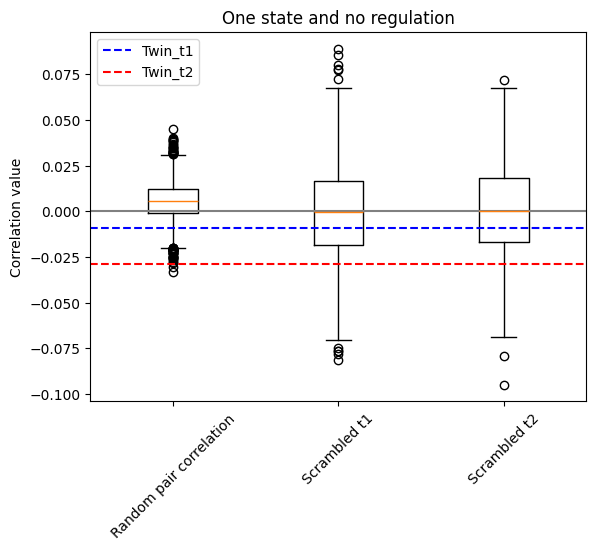

In [21]:
plt.boxplot([random_shuffle['all_values'], twin_scrambled_corr_t1, twin_scrambled_corr_t2])
plt.axhline(twin_pair_correlation_matrix_t1.loc['gene_1','gene_2'], label = "Twin_t1", linestyle = "--", c = "b")
plt.axhline(twin_pair_correlation_matrix_t2.loc['gene_1','gene_2'], label = "Twin_t2", linestyle = "--", c = "r")
plt.ylabel("Correlation value")
plt.xticks([1, 2, 3], ['Random pair correlation', "Scrambled t1", "Scrambled t2"], rotation = 45)  # Fixed spelling
plt.axhline(0, c = "grey")
plt.title("One state and no regulation")
plt.legend()
plt.show()

## Impact of number of twins on correlation fluctuations

In [21]:
t1_clones = clone_ids_shuffled[:n1]
        # t2_clones = clone_ids_shuffled[n1:n2]
        # across_t_clones = clone_ids_shuffled[n1+n2:]
t2_clones

array([], dtype=int64)

In [23]:
import glob
n_genes = 2

gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

n_clones_simulation = 6000
# Replace the specific timestamp with * to match any timestamp
base_pattern = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_B/df_rows_0_1_*_ncells_6000_A_B_rep_{}.csv"
# base_pattern = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/noisy_division/df_rows_0_0_*_ncells_6000_A_to_B_50_percent_rep_{}*.csv"
# base_pattern = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/noisy_division/df_rows_0_0_*_ncells_6000_A_to_B_rep_{}*.csv"
file_paths = []
for rep_i in range(20):  # adjust range as needed
    pattern = base_pattern.format(rep_i)
    matching_files = glob.glob(pattern)
    
    if matching_files:
        # Take the first match (or you could take all if multiple timestamps exist)
        file_paths.append(matching_files[0])
        print(f"Found rep_{rep_i}: {matching_files[0]}")
    else:
        print(f"No file found for rep_{rep_i}")

############################################################################################################################################################################################################################################        
# Initialize storage for all replicates and timepoints
all_results = []

for sim_path in file_paths:
    simulation = pd.read_csv(sim_path)
    t1 = 1
    clone_ids_shuffled = np.random.permutation(n_clones_simulation).astype(np.int64)
    
    # Split into 1:1:2 ratio
    n1 = n2 = n_clones_simulation//4
    time_points = np.arange(1, 48, 1)
    
    # Store results for this replicate
    rep_results = {
        'timepoints': [],
        'twin_corr': [],
        'random_corr': [],
        'pairwise_corr': []  # assuming this is what list_rand_corr was meant to be
    }
    
    for t2 in tqdm(time_points):
        t1_clones = clone_ids_shuffled[:n1]
        t2_clones = clone_ids_shuffled[n1:n2+n2]
        across_t_clones = clone_ids_shuffled[n1+n2:]
        
        # Subset directly
        t2 = np.int64(t2)
        t1 = np.int64(t1)
        t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t1)].reset_index(drop=True)
        t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)].reset_index(drop=True)
        # Across_t: pick exactly one random twin per clone_id
        across_t_twin1 = simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation["replicate"] == 1)].reset_index(drop=True)
        across_t_twin2 = simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation["replicate"] == 2)].reset_index(drop=True)
        
        # Reset index for cleanliness
        t1_twins = t1_twins.reset_index(drop=True)
        t2_twins = t2_twins.reset_index(drop=True)
        all_within_same_time_twins = t2_twins
        across_t_twin1 = across_t_twin1.reset_index(drop=True)
        across_t_twin2 = across_t_twin2.reset_index(drop=True)
        
        all_t1_t2_measurements = pd.concat(
            [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
            ignore_index=True
        )
        
        # Calculate correlations
        pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
            all_t1_t2_measurements, gene_list
        )
        
        twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
            all_t1_t2_measurements, t2_twins, gene_list
        )
        
        # Store results for this timepoint
        rep_results['timepoints'].append(t2)
        rep_results['pairwise_corr'].append(pairwise_gene_gene_correlation_matrix.loc['gene_1', 'gene_2'])
        rep_results['twin_corr'].append(twin_pair_correlation_matrix_t2.loc['gene_1', 'gene_2'])
        rep_results['random_corr'].append(random_pair_correlation_matrix_t2.loc['gene_1', 'gene_2'])
    
    # Add this replicate's results to overall storage
    all_results.append(rep_results)

# Combine all replicates into a single DataFrame
combined_data = []
for i, rep_data in enumerate(all_results):
    for j, timepoint in enumerate(rep_data['timepoints']):
        combined_data.append({
            'replicate': i,
            'timepoint': timepoint,
            'twin_corr': rep_data['twin_corr'][j],
            'random_corr': rep_data['random_corr'][j],
            'pairwise_corr': rep_data['pairwise_corr'][j]
        })

results_df = pd.DataFrame(combined_data)

# Calculate mean ± std for each timepoint
summary_stats = results_df.groupby('timepoint').agg({
    'twin_corr': ['mean', 'std'],
    'random_corr': ['mean', 'std'],
    'pairwise_corr': ['mean', 'std']
}).reset_index()

# Flatten column names
summary_stats.columns = ['timepoint', 'twin_mean', 'twin_std', 'random_mean', 'random_std', 'pairwise_mean', 'pairwise_std']

print("Summary statistics by timepoint:")
print(summary_stats.head())

Found rep_0: /home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_B/df_rows_0_1_08082025_093223_ncells_6000_A_B_rep_0.csv
Found rep_1: /home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_B/df_rows_0_1_08082025_093306_ncells_6000_A_B_rep_1.csv
Found rep_2: /home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_B/df_rows_0_1_08082025_093349_ncells_6000_A_B_rep_2.csv
Found rep_3: /home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_B/df_rows_0_1_08082025_093432_ncells_6000_A_B_rep_3.csv
Found rep_4: /home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_B/df_rows_0_1_08082025_093515_ncells_6000_A_B_rep_4.csv
Found rep_5: /home/mzo5929/Keerthana/grnInference/simulation_data/median_pa

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Summary statistics by timepoint:
   timepoint  twin_mean  twin_std  random_mean  random_std  pairwise_mean  \
0          1   0.001460  0.025044    -0.000948    0.015867      -0.000286   
1          2  -0.002535  0.027122    -0.002403    0.013950      -0.001412   
2          3   0.002713  0.024669    -0.001270    0.011495      -0.000914   
3          4   0.000943  0.024718    -0.001570    0.011381      -0.000263   
4          5   0.003103  0.026754    -0.000900    0.012031       0.000685   

   pairwise_std  
0      0.013039  
1      0.011586  
2      0.010270  
3      0.009715  
4      0.010089  


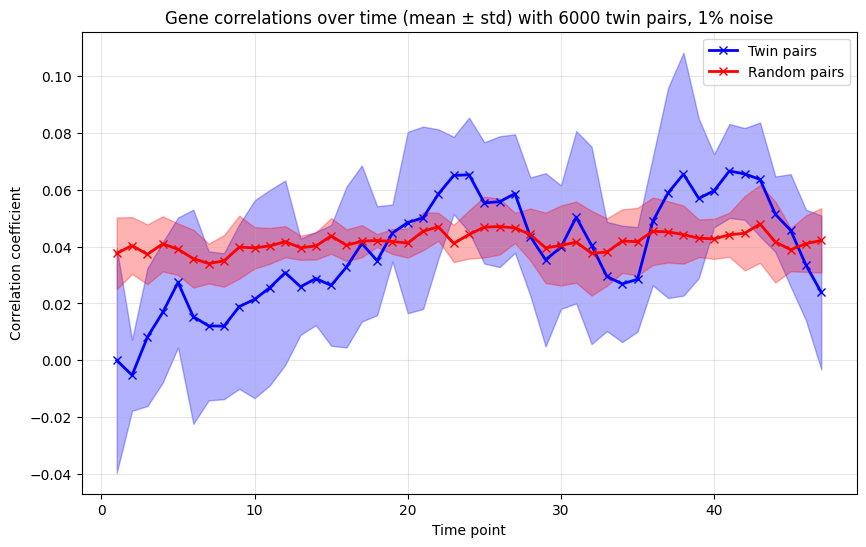

In [48]:
# Now you can easily plot:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Twin pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['twin_mean'], 
         label='Twin pairs', color='blue', linewidth=2, marker = "x")
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['twin_mean'] - summary_stats['twin_std'],
                 summary_stats['twin_mean'] + summary_stats['twin_std'],
                 alpha=0.3, color='blue')

# Random pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['random_mean'], 
         label='Random pairs', color='red', linewidth=2,marker = "x")
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['random_mean'] - summary_stats['random_std'],
                 summary_stats['random_mean'] + summary_stats['random_std'],
                 alpha=0.3, color='red')
# plt.ylim(0, 0.2)
plt.xlabel('Time point')
plt.ylabel('Correlation coefficient')
plt.legend()
plt.title('Gene correlations over time (mean ± std) with 6000 twin pairs, 1% noise')
plt.grid(True, alpha=0.3)
plt.show()

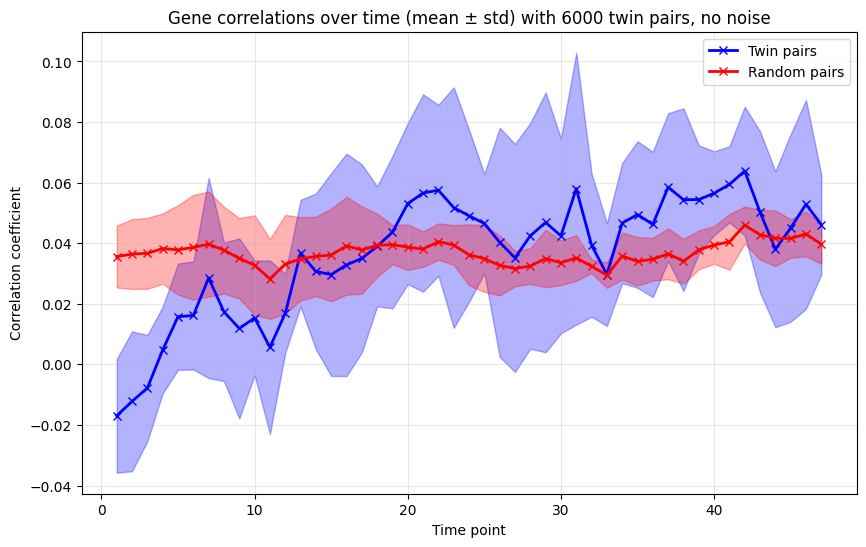

In [44]:
# Now you can easily plot:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Twin pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['twin_mean'], 
         label='Twin pairs', color='blue', linewidth=2, marker = "x")
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['twin_mean'] - summary_stats['twin_std'],
                 summary_stats['twin_mean'] + summary_stats['twin_std'],
                 alpha=0.3, color='blue')

# Random pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['random_mean'], 
         label='Random pairs', color='red', linewidth=2, marker = "x")
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['random_mean'] - summary_stats['random_std'],
                 summary_stats['random_mean'] + summary_stats['random_std'],
                 alpha=0.3, color='red')
# plt.ylim(0, 0.2)
plt.xlabel('Time point')
plt.ylabel('Correlation coefficient')
plt.legend()
plt.title('Gene correlations over time (mean ± std) with 6000 twin pairs, no noise')
plt.grid(True, alpha=0.3)
plt.show()

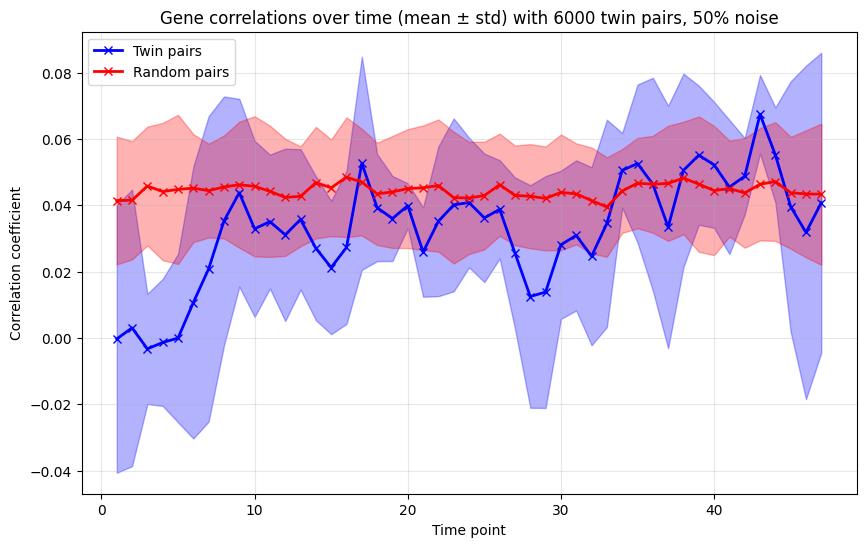

In [42]:
# Now you can easily plot:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Twin pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['twin_mean'], 
         label='Twin pairs', color='blue', linewidth=2, marker = "x")
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['twin_mean'] - summary_stats['twin_std'],
                 summary_stats['twin_mean'] + summary_stats['twin_std'],
                 alpha=0.3, color='blue')

# Random pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['random_mean'], 
         label='Random pairs', color='red', linewidth=2,marker = "x" )
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['random_mean'] - summary_stats['random_std'],
                 summary_stats['random_mean'] + summary_stats['random_std'],
                 alpha=0.3, color='red')
# plt.ylim(0, 0.2)
plt.xlabel('Time point')
plt.ylabel('Correlation coefficient')
plt.legend()
plt.title('Gene correlations over time (mean ± std) with 6000 twin pairs, 50% noise')
plt.grid(True, alpha=0.3)
plt.show()

## Multistate simulations

In [32]:
import pandas as pd
import numpy as np
import glob
import os
from tqdm import tqdm

def split_and_merge_simulations(path_to_simulation_file):
    """
    Splits two simulation files and merges them by taking half the clones from each.
    """
    simulation_1 = pd.read_csv(path_to_simulation_file[0])
    simulation_2 = pd.read_csv(path_to_simulation_file[1])

    clone_ids = sorted(simulation_1['clone_id'].unique())
    half_point = len(clone_ids) // 2

    clones_from_sim1 = clone_ids[:half_point]
    clones_from_sim2 = clone_ids[half_point:]

    sim1_subset = simulation_1[simulation_1['clone_id'].isin(clones_from_sim1)]
    sim2_subset = simulation_2[simulation_2['clone_id'].isin(clones_from_sim2)]

    merged_df = pd.concat([sim1_subset, sim2_subset], ignore_index=True)
    print(f"Merged simulation replicate counts: {merged_df['replicate'].value_counts().to_dict()}")

    return merged_df

def find_all_simulation_pairs(base_dir):
    """
    Find all available simulation pairs from high_k_on and low_k_on folders.
    """
    high_k_pattern = os.path.join(base_dir, "A_B_high_k_on", "*.csv")
    low_k_pattern = os.path.join(base_dir, "A_B_low_k_on", "*.csv")
    
    high_k_files = glob.glob(high_k_pattern)
    low_k_files = glob.glob(low_k_pattern)
    
    print(f"Found {len(high_k_files)} high_k_on files")
    print(f"Found {len(low_k_files)} low_k_on files")
    
    # Extract replicate numbers from filenames
    def extract_rep_number(filepath):
        filename = os.path.basename(filepath)
        # Look for pattern like "_rep_X" where X is the replicate number
        import re
        match = re.search(r'_rep_(\d+)', filename)
        return int(match.group(1)) if match else None
    
    # Create dictionaries mapping rep numbers to file paths
    high_k_dict = {}
    for file in high_k_files:
        rep_num = extract_rep_number(file)
        if rep_num is not None:
            high_k_dict[rep_num] = file
    
    low_k_dict = {}
    for file in low_k_files:
        rep_num = extract_rep_number(file)
        if rep_num is not None:
            low_k_dict[rep_num] = file
    
    # Find common replicate numbers
    common_reps = set(high_k_dict.keys()) & set(low_k_dict.keys())
    
    simulation_pairs = []
    for rep_num in sorted(common_reps):
        pair = [high_k_dict[rep_num], low_k_dict[rep_num]]
        simulation_pairs.append(pair)
        print(f"Rep {rep_num}: {os.path.basename(high_k_dict[rep_num])} + {os.path.basename(low_k_dict[rep_num])}")
    
    print(f"\nFound {len(simulation_pairs)} matching simulation pairs")
    return simulation_pairs

# Configuration
n_genes = 2
gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]
n_clones_simulation = 6000

# Define base directory containing the simulation folders
base_dir = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells"

# Find all available simulation pairs
simulation_pairs = find_all_simulation_pairs(base_dir)

if not simulation_pairs:
    print("No matching simulation pairs found!")
    exit()

############################################################################################################################################################################################################################################        
# Initialize storage for all replicates and timepoints
all_results = []

for pair_idx, sim_pair in enumerate(simulation_pairs):
    print(f"\nProcessing simulation pair {pair_idx + 1}/{len(simulation_pairs)}")
    print(f"High k_on: {os.path.basename(sim_pair[0])}")
    print(f"Low k_on: {os.path.basename(sim_pair[1])}")
    
    try:
        # Create merged simulation using split_and_merge
        simulation = split_and_merge_simulations(sim_pair)
        
        t1 = 1
        clone_ids_shuffled = np.random.permutation(n_clones_simulation).astype(np.int64)
        
        # Split into 1:1:2 ratio
        n1 = n2 = n_clones_simulation//4
        time_points = np.arange(1, 48, 1)
        
        # Store results for this replicate
        rep_results = {
            'timepoints': [],
            'twin_corr': [],
            'random_corr': [],
            'pairwise_corr': []
        }
        
        for t2 in tqdm(time_points, desc=f"Processing timepoints for pair {pair_idx + 1}"):
            t1_clones = clone_ids_shuffled[:n1]
            t2_clones = clone_ids_shuffled[n1:n2+n2]
            across_t_clones = clone_ids_shuffled[n1+n2:]
            
            # Subset directly
            t2 = np.int64(t2)
            t1 = np.int64(t1)
            t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t1)].reset_index(drop=True)
            t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)].reset_index(drop=True)
            
            # Across_t: pick exactly one random twin per clone_id
            across_t_twin1 = simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation["replicate"] == 1)].reset_index(drop=True)
            across_t_twin2 = simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1) & (simulation["replicate"] == 2)].reset_index(drop=True)
            
            # Reset index for cleanliness
            t1_twins = t1_twins.reset_index(drop=True)
            t2_twins = t2_twins.reset_index(drop=True)
            all_within_same_time_twins = t2_twins
            across_t_twin1 = across_t_twin1.reset_index(drop=True)
            across_t_twin2 = across_t_twin2.reset_index(drop=True)
            
            all_t1_t2_measurements = pd.concat(
                [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
                ignore_index=True
            )
            
            # Calculate correlations (you'll need to define these functions)
            pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
                all_t1_t2_measurements, gene_list
            )
            
            twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
                all_t1_t2_measurements, t2_twins, gene_list
            )
            
            # Store results for this timepoint
            rep_results['timepoints'].append(t2)
            rep_results['pairwise_corr'].append(pairwise_gene_gene_correlation_matrix.loc['gene_1', 'gene_2'])
            rep_results['twin_corr'].append(twin_pair_correlation_matrix_t2.loc['gene_1', 'gene_2'])
            rep_results['random_corr'].append(random_pair_correlation_matrix_t2.loc['gene_1', 'gene_2'])
        
        # Add this replicate's results to overall storage
        all_results.append(rep_results)
        print(f"Successfully processed pair {pair_idx + 1}")
        
    except Exception as e:
        print(f"Error processing pair {pair_idx + 1}: {str(e)}")
        continue

print(f"\nSuccessfully processed {len(all_results)} simulation pairs")

# Combine all replicates into a single DataFrame
combined_data = []
for i, rep_data in enumerate(all_results):
    for j, timepoint in enumerate(rep_data['timepoints']):
        combined_data.append({
            'replicate': i,
            'timepoint': timepoint,
            'twin_corr': rep_data['twin_corr'][j],
            'random_corr': rep_data['random_corr'][j],
            'pairwise_corr': rep_data['pairwise_corr'][j]
        })

results_df = pd.DataFrame(combined_data)

# Calculate mean ± std for each timepoint
summary_stats = results_df.groupby('timepoint').agg({
    'twin_corr': ['mean', 'std'],
    'random_corr': ['mean', 'std'],
    'pairwise_corr': ['mean', 'std']
}).reset_index()

# Flatten column names
summary_stats.columns = ['timepoint', 'twin_mean', 'twin_std', 'random_mean', 'random_std', 'pairwise_mean', 'pairwise_std']

print("\nSummary statistics by timepoint:")
print(summary_stats.head())

print(f"\nFinal dataset contains {len(results_df)} observations from {len(all_results)} simulation pairs")

# Optional: Save results
# results_df.to_csv('split_merge_correlation_results_all_reps.csv', index=False)
# summary_stats.to_csv('split_merge_summary_stats_all_reps.csv', index=False)

Found 20 high_k_on files
Found 20 low_k_on files
Rep 0: df_rows_3_3_09082025_201359_ncells_6000_A_B_high_k_on_rep_0.csv + df_rows_2_2_09082025_210256_ncells_6000_A_B_low_k_on_rep_0.csv
Rep 1: df_rows_3_3_09082025_201525_ncells_6000_A_B_high_k_on_rep_1.csv + df_rows_2_2_09082025_210509_ncells_6000_A_B_low_k_on_rep_1.csv
Rep 2: df_rows_3_3_09082025_201647_ncells_6000_A_B_high_k_on_rep_2.csv + df_rows_2_2_09082025_210530_ncells_6000_A_B_low_k_on_rep_2.csv
Rep 3: df_rows_3_3_09082025_201805_ncells_6000_A_B_high_k_on_rep_3.csv + df_rows_2_2_09082025_210551_ncells_6000_A_B_low_k_on_rep_3.csv
Rep 4: df_rows_3_3_09082025_201921_ncells_6000_A_B_high_k_on_rep_4.csv + df_rows_2_2_09082025_210610_ncells_6000_A_B_low_k_on_rep_4.csv
Rep 5: df_rows_3_3_09082025_202040_ncells_6000_A_B_high_k_on_rep_5.csv + df_rows_2_2_09082025_210630_ncells_6000_A_B_low_k_on_rep_5.csv
Rep 6: df_rows_3_3_09082025_202158_ncells_6000_A_B_high_k_on_rep_6.csv + df_rows_2_2_09082025_210652_ncells_6000_A_B_low_k_on_rep_6.csv

Processing timepoints for pair 1: 100%|██████████| 47/47 [00:01<00:00, 30.83it/s]


Successfully processed pair 1

Processing simulation pair 2/20
High k_on: df_rows_3_3_09082025_201525_ncells_6000_A_B_high_k_on_rep_1.csv
Low k_on: df_rows_2_2_09082025_210509_ncells_6000_A_B_low_k_on_rep_1.csv
Merged simulation replicate counts: {1: 294000, 2: 294000}


Processing timepoints for pair 2: 100%|██████████| 47/47 [00:01<00:00, 31.14it/s]


Successfully processed pair 2

Processing simulation pair 3/20
High k_on: df_rows_3_3_09082025_201647_ncells_6000_A_B_high_k_on_rep_2.csv
Low k_on: df_rows_2_2_09082025_210530_ncells_6000_A_B_low_k_on_rep_2.csv
Merged simulation replicate counts: {1: 294000, 2: 294000}


...

Successfully processed pair 18

Processing simulation pair 19/20
High k_on: df_rows_3_3_09082025_203724_ncells_6000_A_B_high_k_on_rep_18.csv
Low k_on: df_rows_2_2_09082025_211112_ncells_6000_A_B_low_k_on_rep_18.csv
Merged simulation replicate counts: {1: 294000, 2: 294000}


Processing timepoints for pair 19: 100%|██████████| 47/47 [00:01<00:00, 31.60it/s]


Successfully processed pair 19

Processing simulation pair 20/20
High k_on: df_rows_3_3_09082025_203840_ncells_6000_A_B_high_k_on_rep_19.csv
Low k_on: df_rows_2_2_09082025_211134_ncells_6000_A_B_low_k_on_rep_19.csv
Merged simulation replicate counts: {1: 294000, 2: 294000}


Processing timepoints for pair 20: 100%|██████████| 47/47 [00:01<00:00, 30.21it/s]

Successfully processed pair 20

Successfully processed 20 simulation pairs

Summary statistics by timepoint:
   timepoint  twin_mean  twin_std  random_mean  random_std  pairwise_mean  \
0          1  -0.000071  0.029401     0.432468    0.007885       0.494781   
1          2   0.009224  0.033730     0.433013    0.008062       0.495108   
2          3   0.013010  0.028049     0.433601    0.007963       0.495685   
3          4   0.004776  0.025385     0.433278    0.006717       0.495873   
4          5  -0.001085  0.028962     0.432673    0.009503       0.495267   

   pairwise_std  
0      0.007841  
1      0.006885  
2      0.007148  
3      0.006029  
4      0.006497  

Final dataset contains 940 observations from 20 simulation pairs


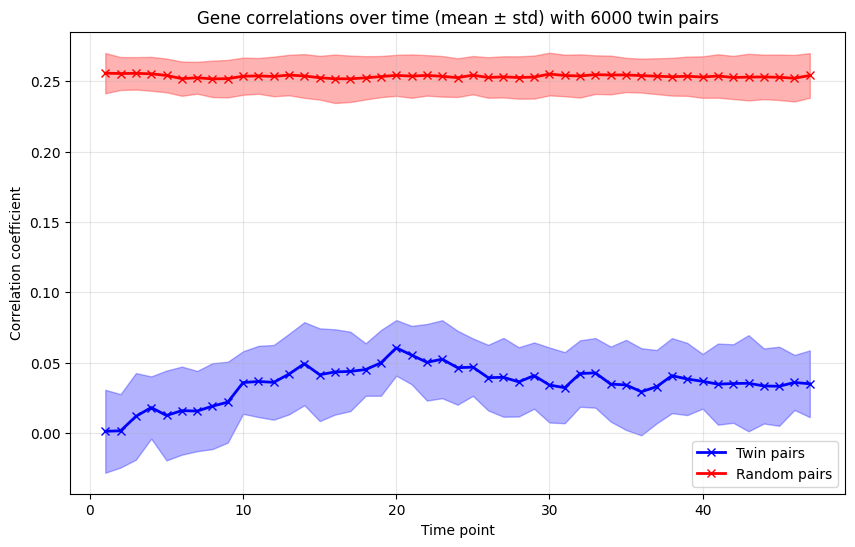

In [31]:
# Now you can easily plot:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Twin pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['twin_mean'], 
         label='Twin pairs', color='blue', linewidth=2, marker = "x")
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['twin_mean'] - summary_stats['twin_std'],
                 summary_stats['twin_mean'] + summary_stats['twin_std'],
                 alpha=0.3, color='blue')

# Random pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['random_mean'], 
         label='Random pairs', color='red', linewidth=2,marker = "x" )
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['random_mean'] - summary_stats['random_std'],
                 summary_stats['random_mean'] + summary_stats['random_std'],
                 alpha=0.3, color='red')
# plt.ylim(0, 0.2)
plt.xlabel('Time point')
plt.ylabel('Correlation coefficient')
plt.legend()
plt.title('Gene correlations over time (mean ± std) with 6000 twin pairs')
plt.grid(True, alpha=0.3)
plt.show()

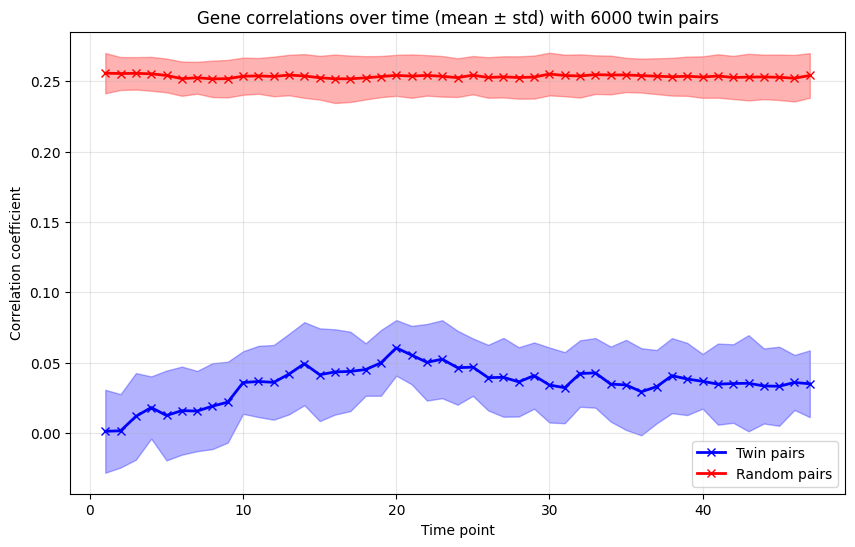

In [30]:
# Now you can easily plot:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Twin pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['twin_mean'], 
         label='Twin pairs', color='blue', linewidth=2, marker = "x")
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['twin_mean'] - summary_stats['twin_std'],
                 summary_stats['twin_mean'] + summary_stats['twin_std'],
                 alpha=0.3, color='blue')

# Random pairs - line with filled error band
plt.plot(summary_stats['timepoint'], summary_stats['random_mean'], 
         label='Random pairs', color='red', linewidth=2,marker = "x" )
plt.fill_between(summary_stats['timepoint'], 
                 summary_stats['random_mean'] - summary_stats['random_std'],
                 summary_stats['random_mean'] + summary_stats['random_std'],
                 alpha=0.3, color='red')
# plt.ylim(0, 0.2)
plt.xlabel('Time point')
plt.ylabel('Correlation coefficient')
plt.legend()
plt.title('Gene correlations over time (mean ± std) with 6000 twin pairs')
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
def split_and_merge_simulations(path_to_simulation_file):
    simulation_1 = pd.read_csv(path_to_simulation_file[0])
    simulation_2 = pd.read_csv(path_to_simulation_file[1])

    clone_ids = sorted(simulation_1['clone_id'].unique())
    half_point = len(clone_ids) // 2

    clones_from_sim1 = clone_ids[:half_point]
    clones_from_sim2 = clone_ids[half_point:]

    sim1_subset = simulation_1[simulation_1['clone_id'].isin(clones_from_sim1)]
    sim2_subset = simulation_2[simulation_2['clone_id'].isin(clones_from_sim2)]

    merged_df = pd.concat([sim1_subset, sim2_subset], ignore_index=True)
    print(merged_df['replicate'].value_counts())

    return merged_df


simulation_1 = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_to_B_high_k_on/df_rows_3_3_09082025_220257_ncells_6000_A_to_B_high_k_on_rep_0.csv"
simulation_2 = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulations_6000_cells/A_to_B_low_k_on/df_rows_2_2_09082025_215156_ncells_6000_A_to_B_low_k_on_rep_17.csv"
simulation = split_and_merge_simulations([simulation_1, simulation_2])

n_genes = 2
gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]
n_clones_simulation = simulation['clone_id'].nunique()

clone_ids = simulation['clone_id'].unique()
clone_ids_shuffled = np.random.permutation(clone_ids)

n1 = n2 = len(clone_ids) // 4

t1_clones = clone_ids_shuffled[:n1]
t2_clones = clone_ids_shuffled[n1:n1 + n2]
across_t_clones = clone_ids_shuffled[n1 + n2:]

t1 = 1
t2 = 10
np.random.seed(4)
clone_ids_shuffled = np.random.permutation(n_clones_simulation)
# # Split into 1:1:2 ratio
n1 = n2 = n_clones_simulation // 4
t1_clones = clone_ids_shuffled[:n1]
t2_clones = clone_ids_shuffled[n1:n1 + n2]
across_t_clones = clone_ids_shuffled[n1 + n2:]
# Subset directly
t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t1)]
t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 = (
    simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1)]
    .groupby('clone_id', group_keys=False)
    .sample(n=1, random_state=None)   # set an int for reproducibility
)

# One (different) cell from the SAME clones at t2
candidates_t2 = simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2)]
# Exclude the exact cell_ids picked at t1 (if cell_id persists across time)
candidates_t2 = candidates_t2[~candidates_t2['cell_id'].isin(across_t_twin1['cell_id'])]
# Now sample one per clone
across_t_twin2 = (
    candidates_t2
    .groupby('clone_id', group_keys=False)
    .sample(n=1, random_state=None)
)

# Reset index for cleanliness
t1_twins = t1_twins.reset_index(drop=True)
t2_twins = t2_twins.reset_index(drop=True)
across_t_twin1 = across_t_twin1.reset_index(drop=True)
across_t_twin2 = across_t_twin2.reset_index(drop=True)
all_t1_t2_measurements = pd.concat(
[t1_twins, t2_twins, across_t_twin1, across_t_twin2],
ignore_index=True
)

# Check number of clones per time step in across_t_clones
print(simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1)]['clone_id'].nunique())
print(simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2)]['clone_id'].nunique())

# --- Step 1: Pairwise gene-gene correlations at t1 ---

# pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
#     all_t1_t2_measurements, gene_list
# )

# scrambled_distribution, _ = get_scrambled_correlations(all_t1_t2_measurements, "gene_1", "gene_2")

twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
        all_t1_t2_measurements, t2_twins, gene_list
)

twin_pair_correlation_matrix_t1, _ = calculate_twin_random_pair_correlations(
        all_t1_t2_measurements, t1_twins, gene_list
)
twin_scrambled_corr_t1 = calculate_twin_pair_correlations(t1_twins, gene_list, "gene_1", "gene_2")
twin_scrambled_corr_t2 = calculate_twin_pair_correlations(t2_twins, gene_list, "gene_1", "gene_2")
# random_shuffle = generate_10k_random_shuffles_optimized(all_t1_t2_measurements, gene_list, n_shuffles=10000, random_state=41)

replicate
1    294000
2    294000
Name: count, dtype: int64
3000
3000
1500


  0%|          | 0/1000 [00:00<?, ?it/s]

1500


  0%|          | 0/1000 [00:00<?, ?it/s]

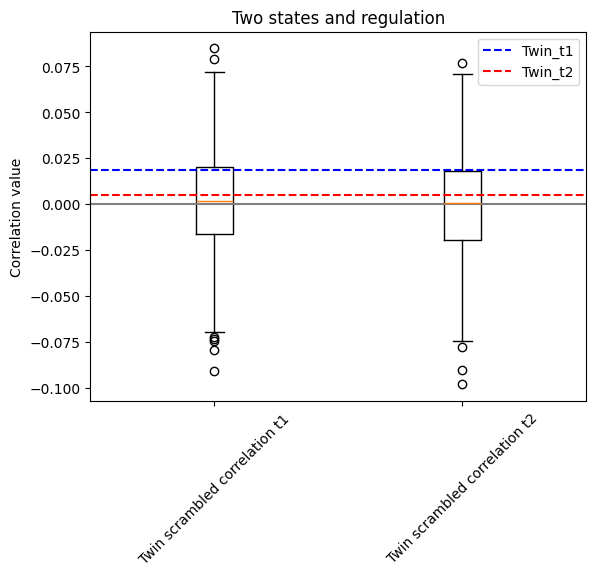

In [51]:
plt.boxplot([twin_scrambled_corr_t1, twin_scrambled_corr_t2])
plt.axhline(twin_pair_correlation_matrix_t1.loc['gene_1','gene_2'], label = "Twin_t1", linestyle = "--", c = "b")
plt.axhline(twin_pair_correlation_matrix_t2.loc['gene_1','gene_2'], label = "Twin_t2", linestyle = "--", c = "r")
plt.ylabel("Correlation value")
plt.xticks([1, 2], [ "Twin scrambled correlation t1", "Twin scrambled correlation t2"], rotation = 45)  # Fixed spelling
plt.axhline(0, c = "grey")
plt.title("Two states and regulation")
plt.legend()
plt.show()

In [138]:
import numpy as np
from scipy.stats import ttest_ind

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    
    # Calculate means
    mean1, mean2 = np.mean(group1), np.mean(group2)
    print(mean1, mean2)
    # Calculate pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*np.var(group1, ddof=1) + (n2-1)*np.var(group2, ddof=1)) / (n1+n2-2))
    print(pooled_std)
    # Cohen's d
    d = (mean1 - mean2) / pooled_std
    return d

# Calculate for your comparisons
d_random_control_t1 = cohens_d(random_pair_random_shuffle['all_values'], twin_subsampling_corr_t1)
print(f"Effect size (control vs t1): {d_random_control_t1:.3f}")
d_random_control_t2 = cohens_d(random_pair_random_shuffle['all_values'], twin_subsampling_corr_t2)
print(f"Effect size (control vs t2): {d_random_control_t2:.3f}")
d_random_t2 = cohens_d(random_shuffle['all_values'], twin_subsampling_corr_t2)
print(f"Effect size (random vs t2): {d_random_t2:.3f}")
d_t1_t2 = cohens_d(twin_subsampling_corr_t1, twin_subsampling_corr_t2)

print(f"Effect size (t1 vs t2): {d_t1_t2:.3f}")

1.06183525382205e-05 -0.03497739970532064
0.013914096748504648
Effect size (control vs t1): 2.515
1.06183525382205e-05 -0.006367648068921252
0.013934705674543305
Effect size (control vs t2): 0.458
0.2558163317792666 -0.006367648068921252
0.010821288949612866
Effect size (random vs t2): 24.229
-0.03497739970532064 -0.006367648068921252
0.020978130399827315
Effect size (t1 vs t2): -1.364


In [129]:
from scipy.stats import ttest_ind
_, p_val_random_t2 = ttest_ind(random_pair_random_shuffle['all_values'], twin_subsampling_corr_t2)
_, p_val_t1_t2 = ttest_ind(twin_subsampling_corr_t1, twin_subsampling_corr_t2)

print(p_val_random_t2, p_val_t1_t2)

0.0 0.0


In [78]:
import numpy as np
from scipy import stats

data = random_shuffle['all_values']
ref_line_1 =  twin_pair_correlation_matrix_t1.loc['gene_1', 'gene_2']
ref_line_2 =  twin_pair_correlation_matrix_t2.loc['gene_1', 'gene_2']
# Core calculations
percentile_1 = stats.percentileofscore(data, ref_line_1)
percentile_2 = stats.percentileofscore(data, ref_line_2)

z_score_1 = (ref_line_1 - np.mean(data)) / np.std(data)
z_score_2 = (ref_line_2 - np.mean(data)) / np.std(data)

t_stat_1, p_val_1 = stats.ttest_1samp(data, ref_line_1)
t_stat_2, p_val_2 = stats.ttest_1samp(data, ref_line_2)

fraction_above_1 = np.mean(data > ref_line_1)
fraction_above_2 = np.mean(data > ref_line_2)

print(f"Percentile of reference line 1: {percentile_1:.2f}")
print(f"Percentile of reference line 2: {percentile_2:.2f}")
print(f"Z-score of reference line 1: {z_score_1:.2f}")
print(f"Z-score of reference line 2: {z_score_2:.2f}")
print(f"T-statistic for reference line 1: {t_stat_1:.2f}, P-value: {p_val_1:.2f}")
print(f"T-statistic for reference line 2: {t_stat_2:.2f}, P-value: {p_val_2:.2f}")
print(f"Fraction of data above reference line 1: {fraction_above_1:.2f}")
print(f"Fraction of data above reference line 2: {fraction_above_2:.2f}")

Percentile of reference line 1: 0.00
Percentile of reference line 2: 0.00
Z-score of reference line 1: -28.42
Z-score of reference line 2: -28.86
T-statistic for reference line 1: 2841.68, P-value: 0.00
T-statistic for reference line 2: 2885.37, P-value: 0.00
Fraction of data above reference line 1: 1.00
Fraction of data above reference line 2: 1.00


## Analyzing all gene-gene correlations

In [79]:
# Shuffle all clone IDs
import os, glob
from tqdm.auto import tqdm
sim_folder = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations//figure_2_simulations_6000_cells/A_to_B/"
pattern = os.path.join(sim_folder, "df_rows_0_1_*_ncells_6000_A_to_B_rep*.csv")
sim_files = sorted(glob.glob(pattern))
np.random.seed(42)
actual_corr = []
all_combinations = [(sim_path, i) for sim_path in sim_files for i in range(1)]

for sim_path, i in tqdm(all_combinations, desc="Processing all simulations"):
    # path_to_matrix = "/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/simulation_details/interaction_matrix_positive.txt"
    simulation = pd.read_csv(sim_path)
    # param_df = pd.read_csv("/home/mzo5929/Keerthana/grnInference/simulation_data/median_parameter_simulations/figure_2_simulation_details/median_param.csv", index_col = 0)
    # param_index = "0_1"
    # gene_params = get_param_data(param_df, param_index)
    # n_genes, interaction_matrix = read_input_matrix(path_to_matrix)
    n_genes = 2
    gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]
    n_clones_simulation = simulation['clone_id'].nunique()
    t1 = 1
    t2 = 10
    clone_ids_shuffled = np.random.permutation(n_clones_simulation)
    # Split into 1:1:2 ratio
    n1 = n2 = n_clones_simulation // 4
    t1_clones = clone_ids_shuffled[:n1]
    t2_clones = clone_ids_shuffled[n1:n1 + n2]
    across_t_clones = clone_ids_shuffled[n1 + n2:]
    # Subset directly
    t1_twins = simulation[(simulation['clone_id'].isin(t1_clones)) & (simulation['time_step'] == t1)]
    t2_twins = simulation[simulation['clone_id'].isin(t2_clones) & (simulation['time_step'] == t2)]
    # Across_t: pick exactly one random twin per clone_id
    # One cell per clone at t1
    across_t_twin1 = (
        simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t1)]
        .groupby('clone_id', group_keys=False)
        .sample(n=1, random_state=None)   # set an int for reproducibility
    )
    # One (different) cell from the SAME clones at t2
    candidates_t2 = simulation[(simulation['clone_id'].isin(across_t_clones)) & (simulation['time_step'] == t2)]
    # Exclude the exact cell_ids picked at t1 (if cell_id persists across time)
    candidates_t2 = candidates_t2[~candidates_t2['cell_id'].isin(across_t_twin1['cell_id'])]
    # Now sample one per clone
    across_t_twin2 = (
        candidates_t2
        .groupby('clone_id', group_keys=False)
        .sample(n=1, random_state=None)
    )
    # Reset index for cleanliness
    t1_twins = t1_twins.reset_index(drop=True)
    t2_twins = t2_twins.reset_index(drop=True)
    across_t_twin1 = across_t_twin1.reset_index(drop=True)
    across_t_twin2 = across_t_twin2.reset_index(drop=True)
    all_t1_t2_measurements = pd.concat(
    [t1_twins, t2_twins, across_t_twin1, across_t_twin2],
    ignore_index=True
    )
    # --- Step 1: Pairwise gene-gene correlations at t1 ---
    
    pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
        all_t1_t2_measurements, gene_list
    )
    actual_corr.append(pairwise_gene_gene_correlation_matrix.loc["gene_1", "gene_2"])

scrambled_distribution, _ = get_scrambled_correlations(all_t1_t2_measurements, "gene_1", "gene_2")

Processing all simulations:   0%|          | 0/20 [00:00<?, ?it/s]

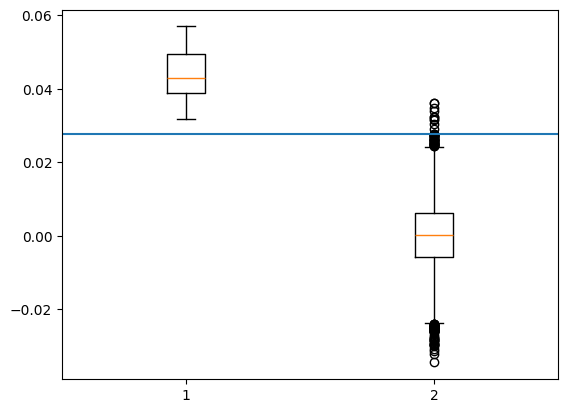

In [86]:
plt.boxplot([actual_corr, scrambled_distribution])
plt.axhline(np.percentile(scrambled_distribution, 99.9))
plt.show()